[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vicradon/ml-workspace/blob/main/shape_detection/notebook.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/vicradon/shape-detection)

In [1]:
IMAGE_DIMENSION=200

import os
os.environ["IMAGE_DIMENSION"] = str(IMAGE_DIMENSION)

In [2]:
%%bash
wget -qO shapegen https://github.com/vicradon/shapegen/releases/download/v0.0.1/shapegen-linux-amd64
cd /kaggle/working
chmod +x shapegen
./shapegen -size $IMAGE_DIMENSION -n 200
unzip -qo shape_dataset_coco.zip


  ╔═══════════════════════════════════════╗
  ║    Shape Dataset Generator  v1.0      ║
  ╚═══════════════════════════════════════╝

  Classes  : 7  (triangle, quadrilateral, pentagon, hexagon, heptagon, octagon, decagon)
  Images   : 200 per class  (1400 total)
  Size     : 200x200 px
  Format   : COCO
  Workers  : 4
  Output   : shape_dataset_coco.zip

  Generating images…
  done [████████████████████████████████████████] 100%  1400/1400 1400/1400
  ✓ Generated 1400 images in 1.943s

  Packing COCO ZIP…
  ✓ ZIP written in 212ms  (4.9 MB)

  ┌─────────────────────────────────────┐
  │  Output → shape_dataset_coco.zip    │
  └─────────────────────────────────────┘



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import random

In [4]:
!pip install torchview

In [5]:
import json
from itertools import islice

with open("/kaggle/working/annotations/instances.json", "r") as annotation_data:
    content = annotation_data.read()
    
annotation_data = json.loads(content)

categories = pd.DataFrame(annotation_data["categories"])
images = pd.DataFrame(annotation_data["images"])
annotations = pd.DataFrame(annotation_data["annotations"])

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import numpy as np

img_to_label = annotations.groupby("image_id")["category_id"].first()
images["label"] = images["id"].map(img_to_label)

label_map = {cat_id: i for i, cat_id in enumerate(sorted(images["label"].unique()))}
images["label"] = images["label"].map(label_map)

class ShapeDataset(Dataset):
    def __init__(self, df, root_dir):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["file_name"])
        image = Image.open(img_path).convert("L")
        image = torch.tensor(np.array(image), dtype=torch.float32) / 255.0
        image = image.unsqueeze(0)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label

dataset = ShapeDataset(images, "/kaggle/working")

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

print({train_size, val_size, test_size})

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


{210, 979, 211}


In [7]:
categories

,id,name,supercategory
0,1,triangle,shape
1,2,quadrilateral,shape
2,3,pentagon,shape
3,4,hexagon,shape
4,5,heptagon,shape
5,6,octagon,shape
6,7,decagon,shape


In [8]:
images.head()

,id,file_name,width,height,label
0,1,images/triangle_0000.png,200,200,0
1,2,images/triangle_0001.png,200,200,0
2,3,images/triangle_0002.png,200,200,0
3,4,images/triangle_0003.png,200,200,0
4,5,images/triangle_0004.png,200,200,0


In [9]:
annotations.head()

,id,image_id,category_id,bbox,area,iscrowd
0,1,1,1,"[53.76, 77.17, 59.14, 67.49]",3991.35,0
1,2,2,1,"[57.86, 61.87, 103.41, 107.1]",11075.22,0
2,3,3,1,"[61.06, 86.38, 96.1, 83.33]",8008.39,0
3,4,4,1,"[28.68, 64.58, 111.53, 108.91]",12146.40,0
4,5,5,1,"[73.02, 41.61, 64.14, 72.08]",4623.00,0


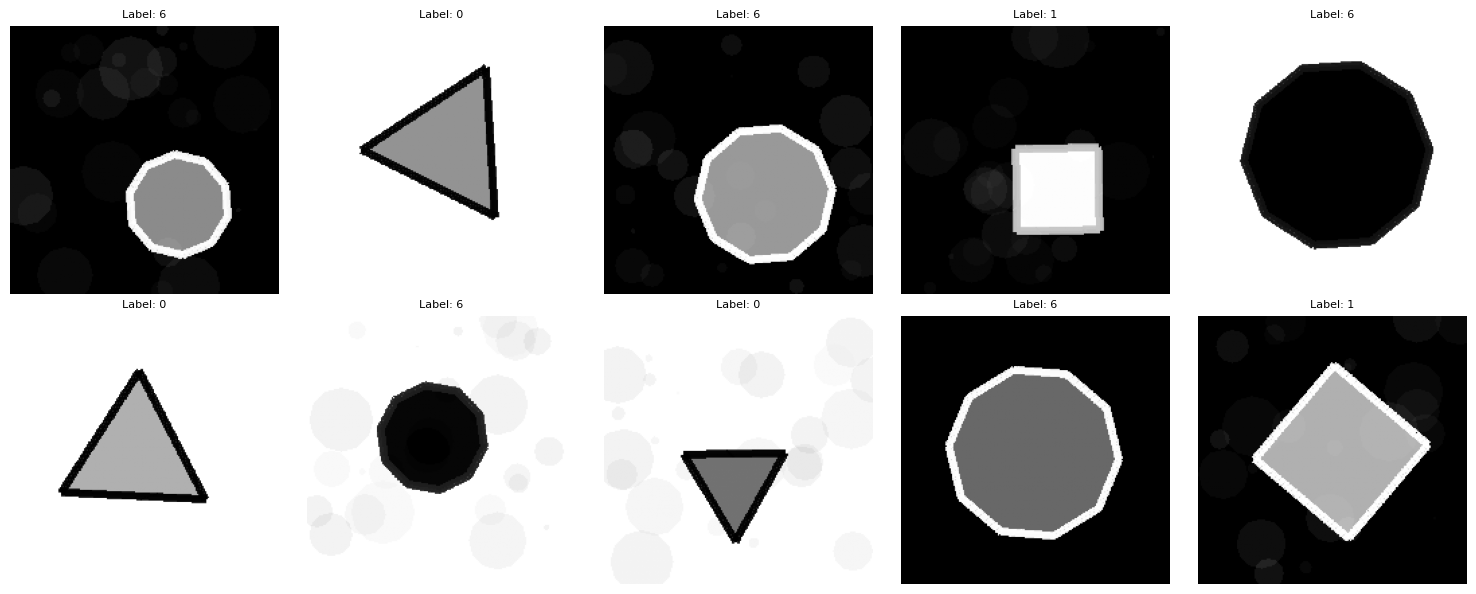

In [10]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))
images_batch, labels_batch = batch

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = images_batch[i].squeeze(0).numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {labels_batch[i].item()}", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [15]:
class ShapeClassifier:
    def __init__(self, network, categories_df, train_loader, val_loader, test_loader, test_dataset,
                 lr=1e-3, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = network.to(self.device)
        self.categories_df = categories_df
        self.class_names = categories_df["name"].tolist()
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.test_dataset = test_dataset
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.history = []

    def train(self, epochs=200, log_every=10):
        for epoch in range(1, epochs + 1):
            # --- Training ---
            self.model.train()
            total_loss, correct, total = 0, 0, 0
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            train_acc = correct / total

            # --- Validation ---
            self.model.eval()
            val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for images, labels in self.val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            val_acc = val_correct / val_total

            self.history.append({
                "epoch": epoch,
                "train_loss": total_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
            })

            if epoch % log_every == 0 or epoch == 1:
                print(f"Epoch {epoch}/{epochs} | "
                      f"Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    def evaluate(self):
        self.model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        accuracy = (all_preds == all_labels).mean()

        print(f"Test Accuracy: {accuracy * 100:.2f}%")
        for i, name in enumerate(self.class_names):
            mask = all_labels == i
            class_acc = (all_preds[mask] == all_labels[mask]).mean() if mask.sum() > 0 else 0
            print(f"  {name}: {class_acc * 100:.2f}%")

        return all_preds, all_labels

    def plot_history(self):
        epochs = [h["epoch"] for h in self.history]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        ax1.plot(epochs, [h["train_loss"] for h in self.history], label="Train Loss")
        ax1.plot(epochs, [h["val_loss"] for h in self.history], label="Val Loss")
        ax1.set_title("Loss")
        ax1.set_xlabel("Epoch")
        ax1.legend()

        ax2.plot(epochs, [h["train_acc"] for h in self.history], label="Train Acc")
        ax2.plot(epochs, [h["val_acc"] for h in self.history], label="Val Acc")
        ax2.set_title("Accuracy")
        ax2.set_xlabel("Epoch")
        ax2.legend()

        plt.suptitle(f"{self.model.__class__.__name__} — Training History", fontweight="bold")
        plt.tight_layout()
        plt.show()

    def visualize_predictions(self, num_samples=5):
        self.model.eval()
        indices = random.sample(range(len(self.test_dataset)), num_samples)
        fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
        if num_samples == 1:
            axes = [axes]

        with torch.no_grad():
            for ax, idx in zip(axes, indices):
                image, label = self.test_dataset[idx]
                output = self.model(image.unsqueeze(0).to(self.device))
                pred = torch.argmax(output, dim=1).item()
                true_name = self.class_names[label.item()]
                pred_name = self.class_names[pred]
                correct = pred == label.item()
                ax.imshow(image.squeeze(0).cpu().numpy(), cmap="gray")
                ax.set_title(
                    f"Pred: {pred_name}\nTrue: {true_name}",
                    color="green" if correct else "red",
                    fontsize=12
                )
                ax.axis("off")

        plt.suptitle(f"{self.model.__class__.__name__} — Predictions", fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

In [17]:
import torch
import torch.nn as nn

class VanillaNeuralNetwork(nn.Module):
    def __init__(self, image_size, num_classes):
        super().__init__()
        self.image_size = image_size
        self.input_dim = image_size * image_size

        self.model = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), self.input_dim)
        return self.model(x)

Epoch 1/200 | Train Loss: 125.6890 | Train Acc: 0.1359 | Val Loss: 14.3942 | Val Acc: 0.1571
Epoch 2/200 | Train Loss: 66.6299 | Train Acc: 0.1757 | Val Loss: 14.8973 | Val Acc: 0.1571
Epoch 4/200 | Train Loss: 63.9690 | Train Acc: 0.1900 | Val Loss: 14.7891 | Val Acc: 0.1333
Epoch 6/200 | Train Loss: 61.6821 | Train Acc: 0.2074 | Val Loss: 13.6080 | Val Acc: 0.2048
Epoch 8/200 | Train Loss: 59.4222 | Train Acc: 0.2063 | Val Loss: 13.4190 | Val Acc: 0.2238
Epoch 10/200 | Train Loss: 58.6814 | Train Acc: 0.2247 | Val Loss: 13.4521 | Val Acc: 0.1905
Epoch 12/200 | Train Loss: 57.3689 | Train Acc: 0.2349 | Val Loss: 13.5662 | Val Acc: 0.1905
Epoch 14/200 | Train Loss: 57.2908 | Train Acc: 0.2206 | Val Loss: 13.5519 | Val Acc: 0.2048
Epoch 16/200 | Train Loss: 56.4267 | Train Acc: 0.2400 | Val Loss: 13.4942 | Val Acc: 0.1857
Epoch 18/200 | Train Loss: 56.5565 | Train Acc: 0.2390 | Val Loss: 13.4182 | Val Acc: 0.1905
Epoch 20/200 | Train Loss: 55.4301 | Train Acc: 0.2400 | Val Loss: 13.6045

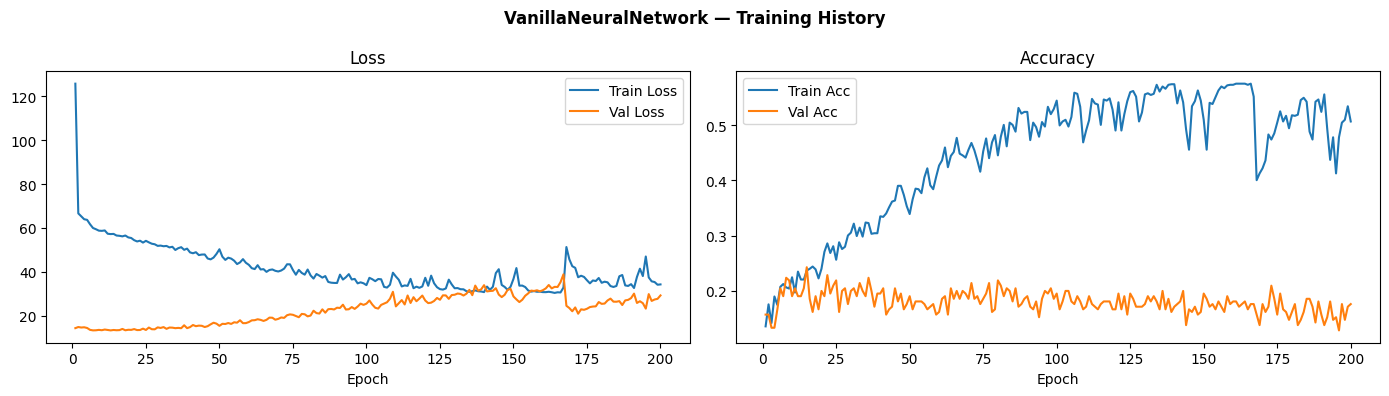

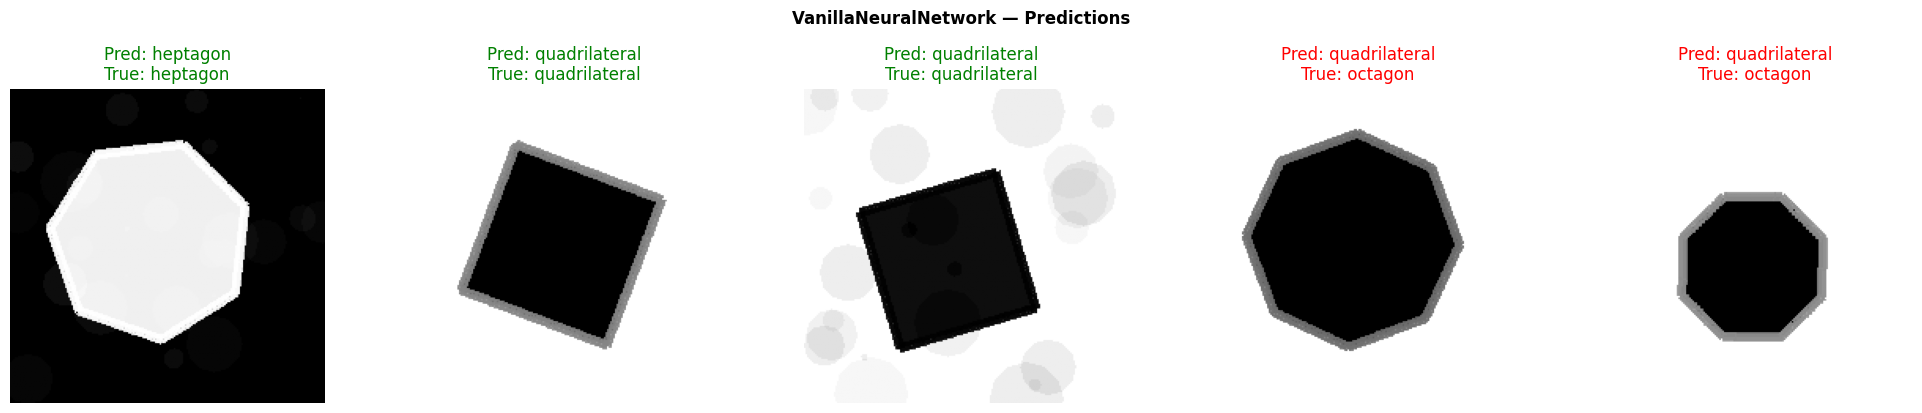

In [18]:
classifier = ShapeClassifier(
    network=VanillaNeuralNetwork(image_size=IMAGE_DIMENSION, num_classes=7),
    categories_df=categories,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    test_dataset=test_dataset,
    lr=1e-3,
)

classifier.train(epochs=200, log_every=2)
classifier.evaluate()
classifier.plot_history()
classifier.visualize_predictions(num_samples=5)

In [21]:
class ConvNet(nn.Module):
    def __init__(self, image_size, num_classes):
        super().__init__()
        self.image_size = image_size

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1, 200, 200) -> (32, 200, 200)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (32, 100, 100)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> (64, 100, 100)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (64, 50, 50)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# -> (128, 50, 50)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (128, 25, 25)
        )

        # derive flat size dynamically so image_size changes don't break anything
        flat_size = self._get_flat_size(image_size)

        self.classifier = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _get_flat_size(self, image_size):
        dummy = torch.zeros(1, 1, image_size, image_size)
        out = self.features(dummy)
        return out.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

Epoch 1/200 | Train Loss: 291.2950 | Train Acc: 0.1542 | Val Loss: 13.6377 | Val Acc: 0.1286
Epoch 10/200 | Train Loss: 58.3029 | Train Acc: 0.2074 | Val Loss: 13.2540 | Val Acc: 0.1905
Epoch 20/200 | Train Loss: 55.1920 | Train Acc: 0.2390 | Val Loss: 12.6977 | Val Acc: 0.2095
Epoch 30/200 | Train Loss: 51.3867 | Train Acc: 0.2789 | Val Loss: 12.4356 | Val Acc: 0.2286
Epoch 40/200 | Train Loss: 47.8544 | Train Acc: 0.3258 | Val Loss: 12.4521 | Val Acc: 0.2667
Epoch 50/200 | Train Loss: 45.5384 | Train Acc: 0.3504 | Val Loss: 12.3736 | Val Acc: 0.2429
Epoch 60/200 | Train Loss: 43.0685 | Train Acc: 0.3871 | Val Loss: 12.8529 | Val Acc: 0.2762
Epoch 70/200 | Train Loss: 42.4398 | Train Acc: 0.3943 | Val Loss: 13.2730 | Val Acc: 0.2667
Epoch 80/200 | Train Loss: 41.6778 | Train Acc: 0.4168 | Val Loss: 13.5628 | Val Acc: 0.2952
Epoch 90/200 | Train Loss: 40.3018 | Train Acc: 0.4229 | Val Loss: 14.5741 | Val Acc: 0.2810
Epoch 100/200 | Train Loss: 40.9528 | Train Acc: 0.4065 | Val Loss: 13

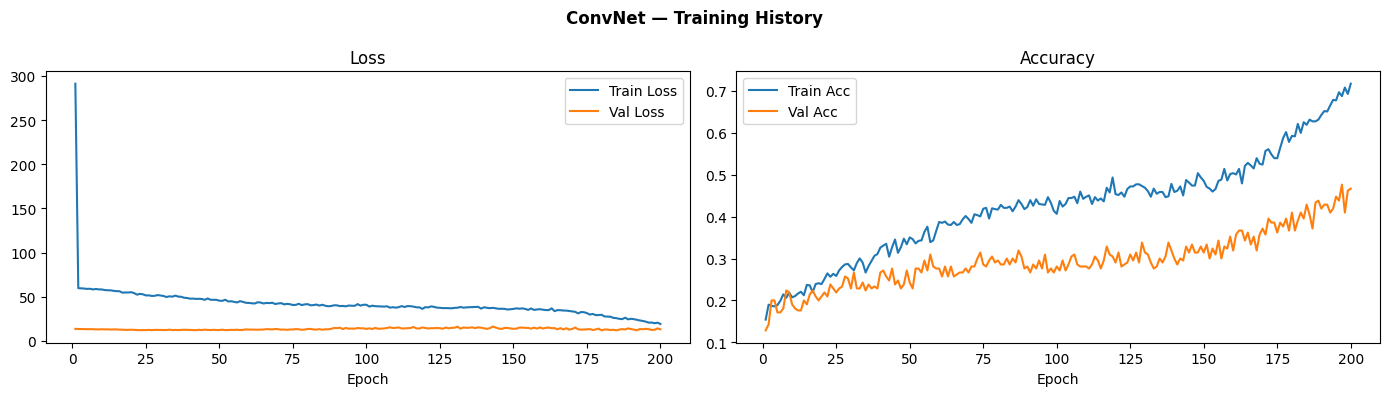

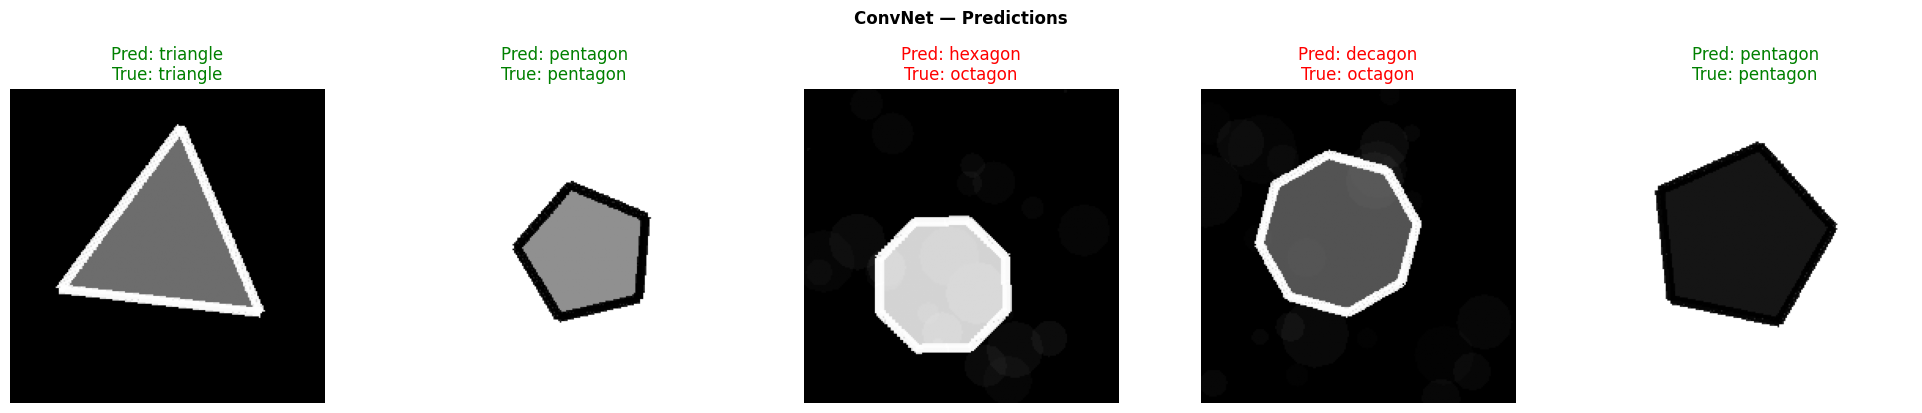

In [22]:
classifier = ShapeClassifier(
    network=ConvNet(image_size=IMAGE_DIMENSION, num_classes=7),
    categories_df=categories,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    test_dataset=test_dataset,
    lr=1e-3,
)

classifier.train(epochs=200, log_every=10)
classifier.evaluate()
classifier.plot_history()
classifier.visualize_predictions(num_samples=5)

In [23]:
from torchview import draw_graph
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display
import os

def compare_architectures(models_and_names, image_size, save_dir="."):
    paths = []
    for model, name in models_and_names:
        graph = draw_graph(
            model,
            input_size=(1, 1, image_size, image_size),
            expand_nested=True,
            graph_name=name,
            save_graph=False,
        )

        dg = graph.visual_graph
        dg.graph_attr.update({
            "dpi": "200",
            "ranksep": "0.6", 
            "nodesep": "0.4", 
            "size": "12,24",
        })
        dg.node_attr.update({
            "fontsize": "11",
            "width": "2.5",
            "height": "0.5",
        })

        out_path = os.path.join(save_dir, name)
        dg.render(filename=out_path, format="png", cleanup=True)
        paths.append((f"{out_path}.png", name))

    fig, axes = plt.subplots(1, len(paths), figsize=(10 * len(paths), 20))
    if len(paths) == 1:
        axes = [axes]

    for ax, (path, name) in zip(axes, paths):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(name, fontsize=14, fontweight="bold", pad=12)
        ax.axis("off")

    plt.suptitle("Architecture Comparison", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

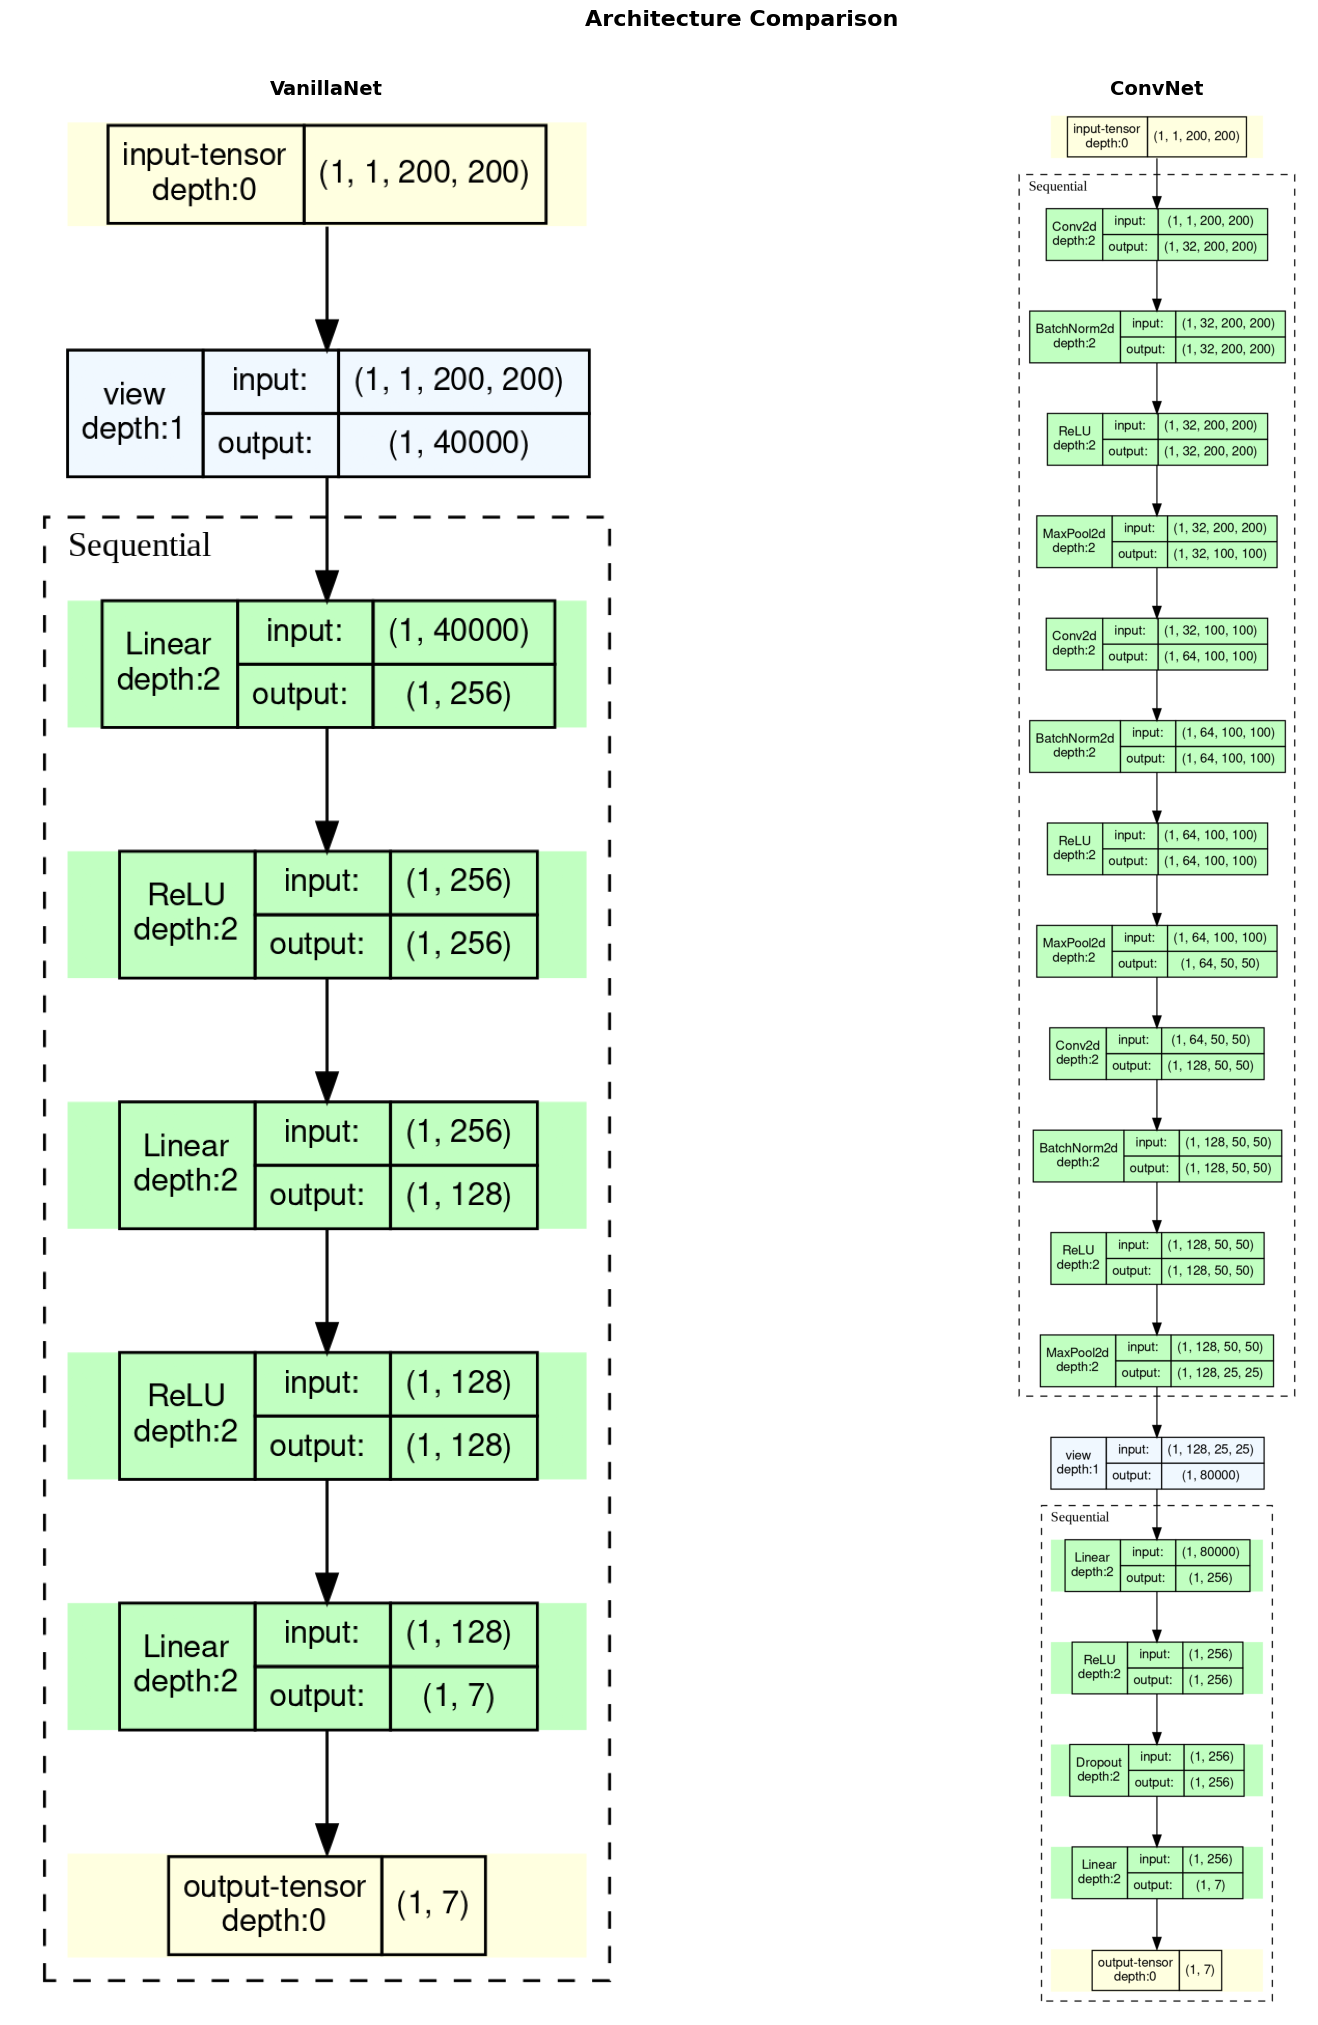

In [24]:
vanilla = VanillaNeuralNetwork(image_size=IMAGE_DIMENSION, num_classes=7)
conv    = ConvNet(image_size=IMAGE_DIMENSION, num_classes=7)

compare_architectures(
    models_and_names=[
        (vanilla, "VanillaNet"),
        (conv,    "ConvNet"),
    ],
    image_size=IMAGE_DIMENSION,
)